# Phân tích Tác động của Hình thức làm việc đến Sức khỏe Tinh thần (Mental Health & Isolation)

**Mục tiêu:** Trả lời câu hỏi cốt lõi - "Làm việc từ xa/hybrid có thực sự ảnh hưởng xấu đến tâm lý?". Chúng ta sẽ bóc tách các yếu tố: Mức độ cô lập xã hội, Tình trạng sức khỏe tinh thần (Anxiety, Burnout, ADHD...) và Sự kiệt sức do làm việc quá giờ.

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [3]:
df = load_raw_data()
df_clean = get_da_data(df)
sns.set_theme(style = 'whitegrid')
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


## 1. Mức độ Cô lập xã hội (Social Isolation) giữa các hình thức làm việc

**Câu hỏi EDA:** Mức độ Cô lập xã hội (Social Isolation Score) của nhóm làm việc Remote có cao hơn đáng kể so với nhóm Onsite không?
Có phải nhóm Remote đang đối mặt với "đại dịch cô đơn"?.

C:\Users\HPC\AppData\Local\Temp\ipykernel_13104\2711983115.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Work_Arrangement', y='Social_Isolation_Score', palette='Set2', showmeans = True, meanline = True,


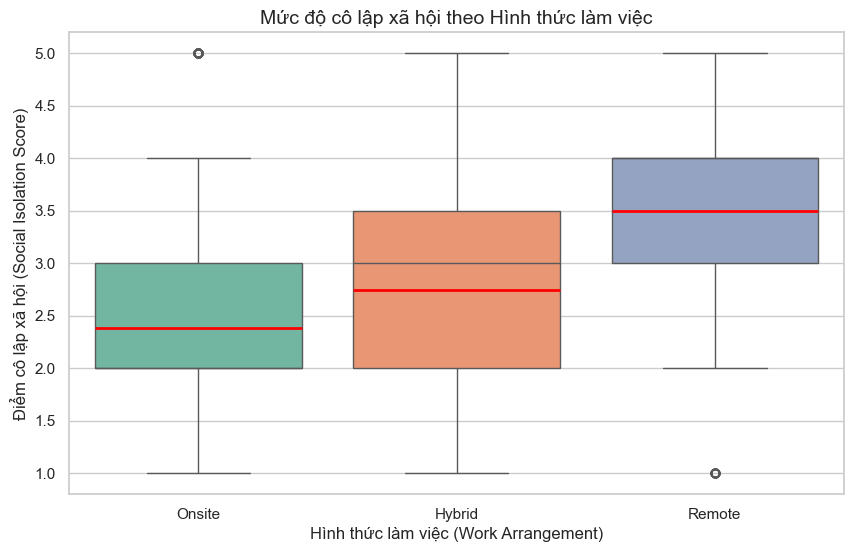

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Work_Arrangement', y='Social_Isolation_Score', palette='Set2', showmeans = True, meanline = True, 
            meanprops={
                'linestyle' : '-',
                'color' : 'red',
                'linewidth' : 2
            })
plt.title('Mức độ cô lập xã hội theo Hình thức làm việc', fontsize=14)
plt.xlabel('Hình thức làm việc (Work Arrangement)')
plt.ylabel('Điểm cô lập xã hội (Social Isolation Score)')
plt.show()

**Nhận xét Insight:** Tương quan giữa Hình thức làm việc & Cô lập xã hội
* Sự tỉ lệ thuận giữa tính linh hoạt và độ cô lập: Hình thức làm việc càng ít tương tác trực tiếp thì mức độ cô lập xã hội càng tăng tiến rõ rệt (Remote > Hybrid > Onsite).

* Remote - Ngưỡng báo động về tâm lý: Nhóm làm việc từ xa có trung vị điểm cô lập cao nhất (~3.5), cho thấy đây là nhóm đối tượng dễ tổn thương nhất về mặt sức khỏe tinh thần trong môi trường số.

* Hybrid - Sự phân hóa cực đoan: Dù có điểm trung bình ổn định hơn Remote, nhưng nhóm Hybrid lại sở hữu dải điểm trải dài từ thấp nhất đến cao nhất (1.0 - 5.0). Điều này chứng tỏ hiệu quả kết nối của Hybrid phụ thuộc hoàn toàn vào cách sắp xếp lịch trình cá nhân.

* Onsite - Vùng an toàn xã hội: Làm việc tại văn phòng duy trì mức độ cô lập thấp nhất (~2.4) và có sự tập trung dữ liệu đồng nhất nhất, khẳng định giá trị của môi trường vật lý trong việc duy trì sợi dây liên kết giữa người với người.

* Điểm dị biệt (Outliers): Sự xuất hiện của các điểm dị biệt ở cả hai đầu (Onsite có người cảm thấy cô lập tuyệt đối, Remote có người cảm thấy kết nối hoàn hảo) cho thấy tính cách cá nhân vẫn là một biến số không thể bỏ qua bên cạnh hình thức làm việc.

## 2. Phân bố các vấn đề Sức khỏe tinh thần (Mental Health Status)
**Câu hỏi EDA:** Các vấn đề về sức khỏe tinh thần (như Anxiety, Burnout, ADHD...) phổ biến nhất ở hình thức làm việc nào?. 
Ngành nghề hoặc nhóm công việc nào đang gặp phải vấn đề tâm lý trầm trọng nhất?

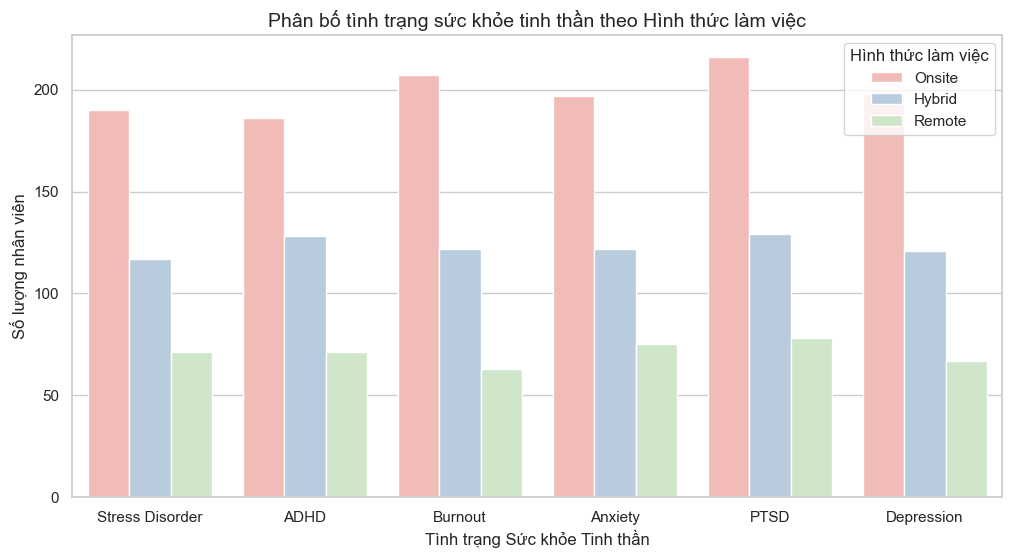

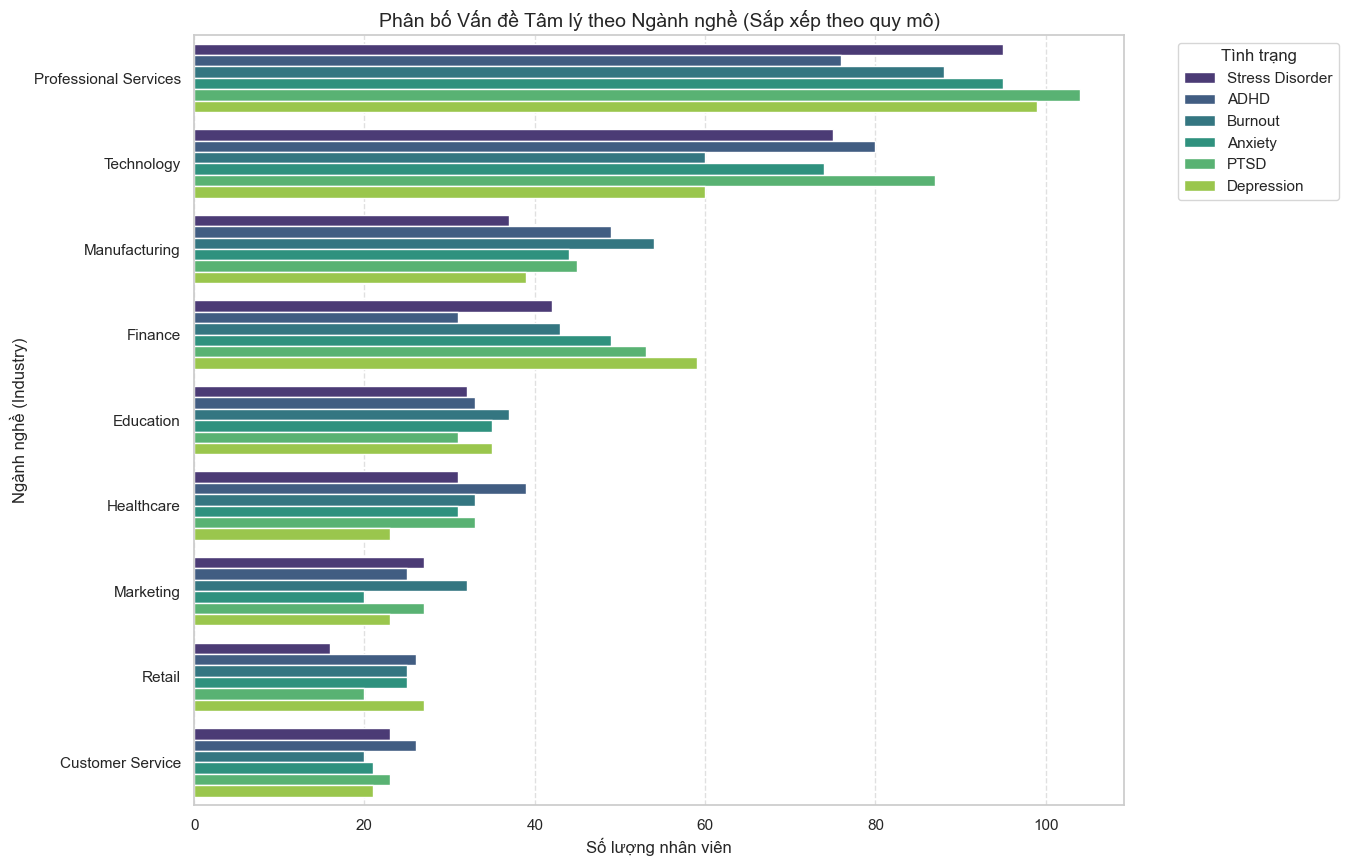

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Mental_Health_Status', hue='Work_Arrangement', palette='Pastel1')
plt.title('Phân bố tình trạng sức khỏe tinh thần theo Hình thức làm việc', fontsize=14)
plt.xlabel('Tình trạng Sức khỏe Tinh thần')
plt.ylabel('Số lượng nhân viên')
plt.legend(title='Hình thức làm việc')
plt.show()

# Phân tích thêm theo ngành nghề
plt.figure(figsize=(12, 10))
# Chuyển sang biểu đồ ngang để tránh chồng chéo tên ngành nghề
sns.countplot(
    data=df, y='Industry', hue='Mental_Health_Status', 
    palette='viridis', order=df['Industry'].value_counts().index
)

plt.title('Phân bố Vấn đề Tâm lý theo Ngành nghề (Sắp xếp theo quy mô)', fontsize=14)
plt.xlabel('Số lượng nhân viên')
plt.ylabel('Ngành nghề (Industry)')
plt.legend(title='Tình trạng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 4.2. Phân tích Insight: Phân bố Tình trạng Sức khỏe Tinh thần
Dựa trên các biểu đồ trực quan hóa, chúng ta ghi nhận những phát hiện thực tế sau về sức khỏe tinh thần của nhân viên:

#### 4.2.1. Tương quan với Hình thức làm việc

* Onsite - Quy mô lớn nhất: Hình thức làm việc tại văn phòng (Onsite) chiếm số lượng nhân viên báo cáo các vấn đề tâm lý cao nhất ở mọi hạng mục.


* Burnout & PTSD là "điểm nóng": Kiệt sức (Burnout) và Rối loạn căng thẳng sau sang chấn (PTSD) là hai tình trạng có số lượng nhân viên Onsite gặp phải đông nhất (vượt ngưỡng 200 người).


* Remote - Tỷ lệ ổn định: Mặc dù số lượng tuyệt đối thấp hơn do quy mô mẫu, nhưng nhóm làm việc từ xa (Remote) vẫn ghi nhận sự hiện diện đồng đều của tất cả các loại rối loạn tâm lý, không có sự chênh lệch quá lớn giữa các hạng mục.

#### 4.2.2. Đặc thù theo Ngành nghề (Industry)

* Nhóm ngành áp lực cao: Dịch vụ chuyên nghiệp (Professional Services) và Công nghệ (Technology) là hai ngành đứng đầu về số lượng báo cáo các vấn đề tâm lý.


* Professional Services: Ghi nhận mức độ lo âu (Anxiety) và trầm cảm (Depression) cao vượt trội so với các ngành khác, tiến sát mốc 100 trường hợp cho mỗi loại.


* Technology: Có sự phân bổ khá nặng về ADHD và Stress Disorder, phản ánh đặc thù công việc đòi hỏi sự tập trung cường độ cao và áp lực thời gian.


* Nhóm ngành dịch vụ thấp hơn: Bán lẻ (Retail) và Chăm sóc khách hàng (Customer Service) có quy mô các vấn đề tâm lý thấp nhất trong danh sách khảo sát.

## 3. Phân tích Mức độ Đóng góp của các Yếu tố đến Kiệt sức (Feature Importance)

**Mục tiêu:** Xác định trọng số đóng góp của từng yếu tố (Giờ làm việc, Tài chính, Cô lập) để tìm ra nguyên nhân gốc rễ dẫn đến Burnout.

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo LabelEncoder
le = LabelEncoder()

# 2. Tạo bản sao dữ liệu để tránh làm hỏng DataFrame gốc
df_model = df_clean.copy()

# 3. Chuyển đổi các cột String sang số
df_model['Work_Arrangement_Num'] = le.fit_transform(df_model['Work_Arrangement'])
df_model['Job_Role_Num'] = le.fit_transform(df_model['Job_Role_Grouped'])
df_model['Region'] = le.fit_transform(df_model['Region'])
df_model['Industry'] = le.fit_transform(df_model['Industry'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

# 4. Xác định danh sách feature mới (toàn bộ là số)
features = [
    'Hours_Per_Week', 
    'Salary_Midpoint', 
    'Social_Isolation_Score', 
    'Work_Life_Balance_Score', 
    'Work_Arrangement_Num', 
    'Job_Role_Num',
    'Age',
    'Industry',
    'Gender',
    'Region'
]

X = df_model[features]
y = df_model['Burnout_Level']

# 5. Chạy mô hình để xem mức độ đóng góp
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# 6. Trình bày kết quả
importance = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

                   Feature  Importance
6                      Age    0.187329
0           Hours_Per_Week    0.176978
7                 Industry    0.105655
9                   Region    0.097815
5             Job_Role_Num    0.094067
1          Salary_Midpoint    0.085675
3  Work_Life_Balance_Score    0.084919
2   Social_Isolation_Score    0.082370
8                   Gender    0.049436
4     Work_Arrangement_Num    0.035757


C:\Users\HPC\AppData\Local\Temp\ipykernel_13104\449805230.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


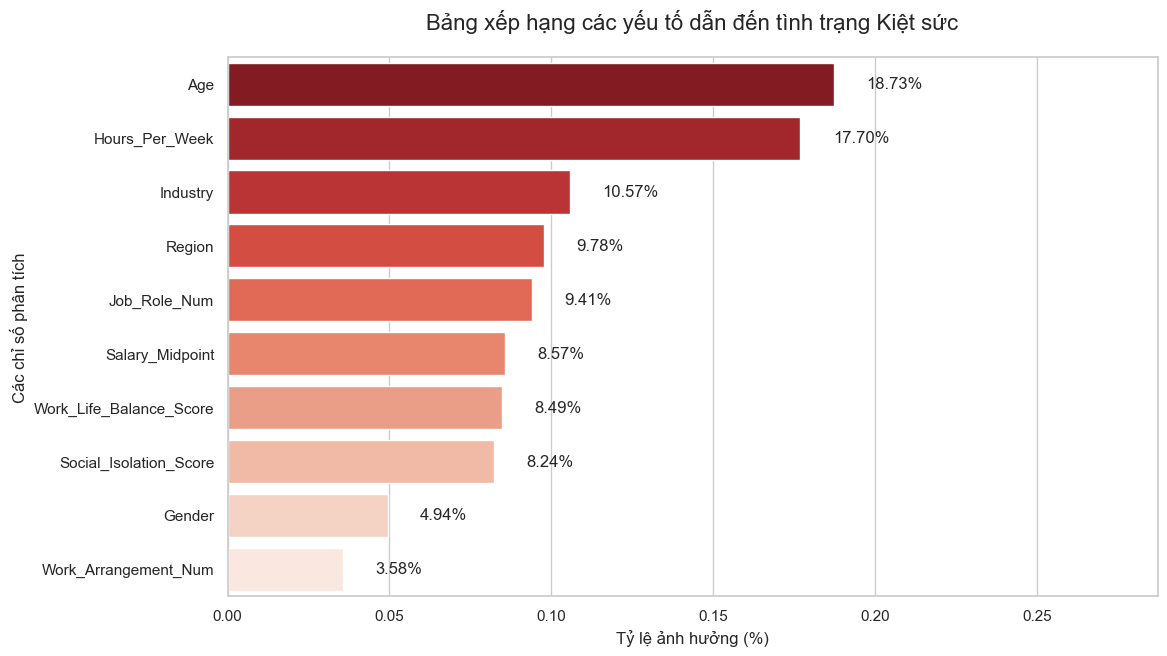

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trích xuất mức độ quan trọng và sắp xếp
feature_importance = pd.DataFrame({
    'Yếu tố': features,
    'Mức độ đóng góp': rf.feature_importances_
}).sort_values(by='Mức độ đóng góp', ascending=False)

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Sử dụng màu sắc để làm nổi bật (màu đậm cho yếu tố quan trọng nhất)
colors = sns.color_palette("Reds_r", len(feature_importance))

ax = sns.barplot(
    x='Mức độ đóng góp', 
    y='Yếu tố', 
    data=feature_importance, 
    palette=colors
)

# 3. Thêm nhãn số liệu trực tiếp lên thanh biểu đồ
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01, p.get_y() + p.get_height()/2, 
            '{:1.2f}%'.format(width*100), 
            va='center')

plt.title('Bảng xếp hạng các yếu tố dẫn đến tình trạng Kiệt sức', fontsize=16, pad=20)
plt.xlabel('Tỷ lệ ảnh hưởng (%)', fontsize=12)
plt.ylabel('Các chỉ số phân tích', fontsize=12)
plt.xlim(0, max(feature_importance['Mức độ đóng góp']) + 0.1) # Tạo không gian cho nhãn chữ

plt.show()

### Nhận xét: Phân tích trọng số đóng góp vào tình trạng Kiệt sức (Dữ liệu đa biến)
Sau khi đưa thêm các yếu tố nhân khẩu học và môi trường vào mô hình Random Forest, trọng số đóng góp của các tính năng đã thay đổi, cho thấy một bức tranh phức tạp và thực tế hơn về nguyên nhân dẫn đến Burnout:

1. Tuổi tác và Thời gian là hai "ngòi nổ" hàng đầu:

* Độ tuổi (Age): Đóng góp tới 18.73%. Đây là yếu tố quan trọng nhất, cho thấy ngưỡng chịu đựng áp lực và khả năng phục hồi tâm lý thay đổi rõ rệt theo từng nhóm tuổi.

* Số giờ làm việc (Hours_Per_Week): Đứng sát nút với 17.70%. Dù không còn chiếm tỷ trọng tuyệt đối như lần chạy trước, thời gian lao động vẫn là yếu tố định lượng then chốt gây ra sự quá tải.

2. Sự chi phối của bối cảnh ngành nghề và khu vực:

* Ngành nghề (Industry): Chiếm 10.57%. Đặc thù áp lực của từng lĩnh vực khác nhau tạo ra các mức rủi ro kiệt sức khác nhau.

* Khu vực (Region): Đóng góp 9.78%, phản ánh ảnh hưởng của văn hóa làm việc và điều kiện sống tại từng địa phương.

3. Nhóm yếu tố Công việc và Chất lượng sống (Đồng hạng):

* Vị trí công việc (Job_Role_Num): 9.41%

* Thu nhập (Salary_Midpoint): 8.57%

* Sự cân bằng (Work_Life_Balance_Score): 8.49%

* Cô lập xã hội (Social_Isolation_Score): 8.24%

    Bốn yếu tố này có trọng số cực kỳ sát nhau. Nó tạo thành một tổ hợp "Hệ sinh thái công việc". Khi các yếu tố này không được đảm bảo đồng thời, chúng sẽ cộng hưởng cùng với tuổi tác và giờ làm để đẩy nhanh quá trình Burnout.

4. Giới tính và Hình thức làm việc có ảnh hưởng thấp nhất:

* Giới tính (Gender): Chiếm 4.94%.

* Hình thức làm việc (Work_Arrangement_Num): Chỉ chiếm 3.58%.

Kết quả này một lần nữa khẳng định: Việc bạn là Nam hay Nữ, hay việc bạn làm Remote/Onsite không quan trọng bằng việc bạn bao nhiêu tuổi, làm bao nhiêu giờ và thuộc ngành nghề nào.

## 4. Phân tích mức độ tương quan giữa số giờ làm việc với mức độ burn out 
**Mục tiêu:** Hiểu rõ tại sao số giờ làm việc (Hour_per_week) là yếu tố ảnh hưởng nhất đến mức độ burn out

## 5.Phân tích mức độ tương quan giữa độ tuổi và mức độ burn out
**Mục tiêu:** Hiểu rõ tại sao độ tuổi là yếu tố ảnh hưởng cao nhất đến mức độ burn out 